In [ ]:
import pandas as pd
df = pd.read_parquet(r"C:\hackathon\PS-03\model\final\finaldataset.parquet")
df

,Date,latitude,longitude,pm25,pm10,img_mir_radiance,img_mir_temp,img_swir_radiance,img_tir1_radiance,img_tir1_temp,...,img_vis_albedo,img_wv_radiance,img_wv_temp,PBLH,avg_population,sat_azimuth,sat_elevation,sun_azimuth,sun_elevation,lulc
0,2021-01-15,8.514909,76.943588,16.520000,37.840000,0.043679,290.781586,1.312773,0.520951,263.632935,...,13.258400,0.092012,231.339325,667.463562,176540.915286,14840.473684,7822.263158,20924.368421,5600.421053,16.0
1,2021-01-15,8.524112,76.936057,33.000000,51.750000,0.043498,290.683807,1.350298,0.521067,263.644684,...,13.710799,0.091692,231.251984,667.463562,176540.915286,14838.789474,7821.000000,20922.631579,5600.157895,16.0
2,2021-01-15,8.524112,76.936057,33.000000,38.500000,0.043498,290.683807,1.350298,0.521067,263.644684,...,13.710799,0.091692,231.251984,667.463562,176540.915286,14838.789474,7821.000000,20922.631579,5600.157895,16.0
3,2021-01-15,8.524112,76.936057,33.000000,33.500000,0.043498,290.683807,1.350298,0.521067,263.644684,...,13.710799,0.091692,231.251984,667.463562,176540.915286,14838.789474,7821.000000,20922.631579,5600.157895,16.0
4,2021-01-15,8.524112,76.936057,33.000000,39.000000,0.043498,290.683807,1.350298,0.521067,263.644684,...,13.710799,0.091692,231.251984,667.463562,176540.915286,14838.789474,7821.000000,20922.631579,5600.157895,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395094,2023-11-15,34.065992,74.827902,61.900000,69.700000,0.052602,295.190308,0.997179,0.814765,289.112488,...,12.606668,0.168452,247.971497,2206.166504,152346.441429,16816.000000,5065.187500,20389.187500,3518.312500,16.0
395095,2023-11-15,34.065992,74.827902,61.900000,70.000000,0.052602,295.190308,0.997179,0.814765,289.112488,...,12.606668,0.168452,247.971497,2206.166504,152346.441429,16816.000000,5065.187500,20389.187500,3518.312500,16.0
395096,2023-11-15,34.065992,74.827902,61.900000,188.100000,0.052602,295.190308,0.997179,0.814765,289.112488,...,12.606668,0.168452,247.971497,2206.166504,152346.441429,16816.000000,5065.187500,20389.187500,3518.312500,16.0
395097,2023-11-15,34.065992,74.827902,61.900000,187.500000,0.052602,295.190308,0.997179,0.814765,289.112488,...,12.606668,0.168452,247.971497,2206.166504,152346.441429,16816.000000,5065.187500,20389.187500,3518.312500,16.0


In [ ]:
import pandas as pd
import numpy as np
import warnings
import optuna
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import shap
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# === Load dataset ===
tqdm.write("📥 Loading dataset...")
df = df
df= df.sample(n=100000,replace=True,random_state =42)
# === Feature Engineering ===
tqdm.write("⚒ Performing feature engineering...")
df['tir_radiance_diff'] = df['img_tir1_radiance'] - df['img_tir2_radiance']
df['pm25'] = df['pm25']
df['smoke_index_temp'] = df['img_mir_temp'] / (df['img_vis_radiance'] + 1e-6)
df['temp_diff_tir'] = df['img_tir1_temp'] - df['img_tir2_temp']
df['sat_view_obliquity'] = 90 - df['sat_elevation']   # how slanted the satellite view is
df['sun_view_angle_diff'] = abs(df['sun_azimuth'] - df['sat_azimuth'])  # illumination-view difference
df['sun_obliquity'] = 90 - df['sun_elevation']  # how low the sun is


features = [
    'latitude', 'longitude', 'img_mir_radiance', #'img_mir_temp', 'img_tir1_temp','img_tir2_temp','img_tir1_radiance', 'img_tir2_radiance', 'img_wv_radiance', 'img_wv_temp','sat_view_obliquity,'sun_elevation','sat_azimuth', 
    'img_swir_radiance', 'img_vis_radiance','smoke_index_temp','sun_azimuth', 
    'img_vis_albedo','avg_population','PBLH', 'lulc', 'tir_radiance_diff','sun_view_angle_diff','sun_obliquity','sat_elevation',
    'temp_diff_tir'
]
target = 'pm25'

df = df.dropna(subset=features + [target])
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Scaling ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === RFECV ===
tqdm.write("🧪 Step 1: RFECV for initial feature pruning...")
cv = KFold(n_splits=10, shuffle=True, random_state=42)
rfecv = RFECV(estimator=Ridge(), step=1, cv=cv, scoring='r2', min_features_to_select=20)
rfecv.fit(X_train_scaled, y_train)

X_train_selected = rfecv.transform(X_train_scaled)
X_test_selected = rfecv.transform(X_test_scaled)
selected_features = X.columns[rfecv.support_]
removed_features_rfecv = list(X.columns[~rfecv.support_])
tqdm.write(f"❌ RFECV removed features: {removed_features_rfecv}")
tqdm.write(f"✅ Features after RFECV: {list(selected_features)}")

X_all_scaled = scaler.transform(X)
X_reduced = rfecv.transform(X_all_scaled)
y_reduced = y.reset_index(drop=True)

# === Optuna Tuning ===
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 600),
        'max_depth': trial.suggest_int('max_depth', 6, 30),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'random_state': 42,
        'device': 'gpu'
    }
    model = LGBMRegressor(**params)
    return cross_val_score(model, X, y, cv=5, scoring='r2').mean()

tqdm.write("🔍 Step 2: Tuning LightGBM with Optuna...")
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True)
best_lgb_params = study_lgb.best_params

# === Train Final Model ===
lgb_best = LGBMRegressor(**best_lgb_params)
lgb_best.fit(X_train_selected, y_train)

# === Evaluation ===
y_pred = lgb_best.predict(X_test_selected)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n📊 Model Evaluation:")
print(f"R²: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")









📥 Loading dataset...
⚒ Performing feature engineering...
🧪 Step 1: RFECV for initial feature pruning...


[I 2025-08-08 01:24:09,022] A new study created in memory with name: no-name-a784cb88-9f51-45f1-a237-6c194f30e4ff


❌ RFECV removed features: []
✅ Features after RFECV: ['latitude', 'longitude', 'img_mir_radiance', 'img_swir_radiance', 'img_vis_radiance', 'smoke_index_temp', 'img_vis_albedo', 'avg_population', 'PBLH', 'lulc', 'tir_radiance_diff', 'sun_view_angle_diff', 'sun_obliquity', 'sat_elevation', 'temp_diff_tir']
🔍 Step 2: Tuning LightGBM with Optuna...


  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3590
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 15
[LightGBM] [Info] Using GPU Device: Intel(R) Iris(R) Xe Graphics, Vendor: Intel(R) Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 15 dense feature groups (1.22 MB) transferred to GPU in 0.003260 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 48.752381
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3589
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 15
[LightGBM] [Info] Using GPU Device: Intel(R) Iris(R) Xe Graphics, Vendor: Intel(R) Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin 

In [9]:
# === Permutation Importance ===
tqdm.write("🧮 Step 3: Permutation importance...")
perm = permutation_importance(lgb_best, X_test_selected, y_test, n_repeats=10, random_state=42)
perm_importances = pd.DataFrame({'Feature': selected_features, 'Importance': perm.importances_mean})
perm_importances = perm_importances.sort_values(by='Importance', ascending=False)
print("\n📌 Permutation Importance:")
print(perm_importances)

🧮 Step 3: Permutation importance...

📌 Permutation Importance:
                Feature  Importance
13       avg_population    0.171762
21          sun_azimuth    0.169463
18  sun_view_angle_diff    0.142337
14                 PBLH    0.095237
24        temp_diff_tir    0.067010
0              latitude    0.066320
1             longitude    0.066073
6      smoke_index_temp    0.048628
19        sun_obliquity    0.045561
2      img_mir_radiance    0.042545
23          sat_azimuth    0.042416
4     img_swir_radiance    0.038449
5      img_vis_radiance    0.036310
22        sat_elevation    0.035527
17   sat_view_obliquity    0.034489
16    tir_radiance_diff    0.033051
20        sun_elevation    0.030465
8        img_vis_albedo    0.020467
15                 lulc    0.019051
9       img_wv_radiance    0.013887
3          img_mir_temp    0.009941
10          img_wv_temp    0.003974
11          cloud_score    0.000199
7        inversion_flag    0.000024
12           cloud_flag    0.000000


📈 Step 4: SHAP value analysis...


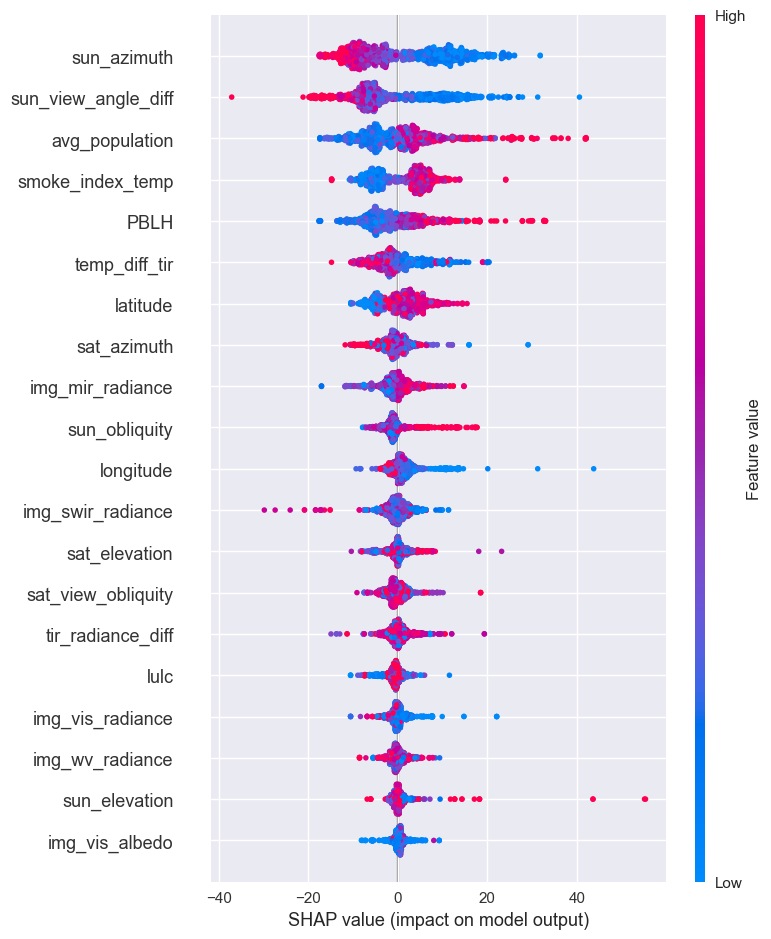

<Figure size 800x550 with 0 Axes>

In [10]:
tqdm.write("📈 Step 4: SHAP value analysis...")
# explainer = shap.Explainer(rf_best, X_train_selected)
# shap_values = explainer(X_test_selected,check_addivity = False)
# Limit to 1000 rows, for example

# Sample 10 rows from the original DataFrame before transformation
X_shap_sample_df = X_test[selected_features].reset_index(drop=True).sample(n=1500, random_state=42)

# Scale and transform to match model input
X_shap_sample_scaled = scaler.transform(X_shap_sample_df)
X_shap_sample_selected = rfecv.transform(X_shap_sample_scaled)

# Compute SHAP values
explainer = shap.TreeExplainer(lgb_best)
shap_values = explainer(X_shap_sample_selected)

# And plot
plt.figure()
shap.summary_plot(shap_values, features=X_shap_sample_df, feature_names=selected_features)
plt.tight_layout()
plt.show()

In [11]:
# === Error Clustering ===
tqdm.write("📉 Step 5: Error clustering...")
errors = y_test - y_pred
error_df = pd.DataFrame(X_test[selected_features])
error_df['Error'] = errors.values

high_error_indices = error_df['Error'].abs() > np.percentile(abs(errors), 90)
error_cluster = error_df.loc[high_error_indices]
print("\n🔥 Top 10% Error Cluster:")
print(error_cluster.describe())

📉 Step 5: Error clustering...

🔥 Top 10% Error Cluster:
          latitude    longitude  img_mir_radiance  img_mir_temp  \
count  1929.000000  1929.000000       1929.000000   1929.000000   
mean     25.531908    80.885671          0.079877    303.943661   
std       4.908389     6.373347          0.025584     10.528744   
min       8.524112    72.579261          0.008166    256.368652   
25%      22.626966    76.791360          0.064807    300.264496   
50%      25.609324    77.064466          0.076306    304.354858   
75%      28.608282    85.211174          0.091610    308.874329   
max      34.065992    93.927888          0.142040    320.965363   

       img_swir_radiance  img_vis_radiance  smoke_index_temp  inversion_flag  \
count        1929.000000       1929.000000       1929.000000     1929.000000   
mean            1.291782          6.127160         65.424880        0.971488   
std             0.364497          4.508926         26.667935        0.166474   
min             0.50

In [12]:
# === Flag Misleading Features ===
tqdm.write("🧠 Step 6: Flagging misleading features...")
flagged = []
for feature in selected_features:
    perm_value = perm_importances.loc[perm_importances['Feature'] == feature, 'Importance'].values[0]
    shap_val = np.mean(np.abs(shap_values[:, selected_features.get_loc(feature)].values))
    correlation = error_df[feature].corr(error_df['Error'])

    if perm_value < 0.001 and shap_val > 0.01 and abs(correlation) > 0.2:
        flagged.append((feature, perm_value, shap_val, correlation))

flagged_df = pd.DataFrame(flagged, columns=["Feature", "Permutation Importance", "SHAP", "Correlation with Error"])
print("\n🚨 Misleading Features (Low Perm, High SHAP, High Corr with Error):")
print(flagged_df)

🧠 Step 6: Flagging misleading features...

🚨 Misleading Features (Low Perm, High SHAP, High Corr with Error):
Empty DataFrame
Columns: [Feature, Permutation Importance, SHAP, Correlation with Error]
Index: []
